In [5]:
import os
os.chdir("/home/piai/Desktop/git/1 Big Data 분석 기초")
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
import matplotlib
%matplotlib inline

In [7]:
df_raw = pd.read_csv('FITNESS_정제.csv', encoding='euc-kr')
df_raw.head()

,NAME,GENDER,AGE,AGEGROUP,WEIGHT,OXY,RUNTIME,RUNPULSE,RSTPULSE,MAXPULSE,BIRTH
0,Donna,여성,42,40대,68.15,59.571,8.17 SEC,166,40,172,1976-04-05
1,Gracie,NaN,38,30대,81.87,60.055,8.63 SEC,170,48,186,1986-09-06
2,Luanne,여성,43,40대,85.84,54.297,8.65 SEC,156,45,168,1978-04-07
3,Mimi,여성,50,50대,70.87,54.625,8.92 SEC,146,48,155,1966-08-08
4,Chris,남성,49,40대,NaN,49.156,8.95 SEC,180,44,185,1977-02-09


In [8]:
df_raw.isnull()

,NAME,GENDER,AGE,AGEGROUP,WEIGHT,OXY,RUNTIME,RUNPULSE,RSTPULSE,MAXPULSE,BIRTH
0,False,False,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,True,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False,False,False,False


In [9]:
df_raw.isna()

,NAME,GENDER,AGE,AGEGROUP,WEIGHT,OXY,RUNTIME,RUNPULSE,RSTPULSE,MAXPULSE,BIRTH
0,False,False,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,True,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False,False,False,False


In [10]:
df_raw.isnull().sum()

NAME        0
GENDER      1
AGE         0
AGEGROUP    0
WEIGHT      2
OXY         0
RUNTIME     0
RUNPULSE    0
RSTPULSE    0
MAXPULSE    0
BIRTH       0
dtype: int64

In [15]:
df_raw['GENDER'].fillna("여성", inplace = True)
df_raw.isnull().sum()

NAME        0
GENDER      0
AGE         0
AGEGROUP    0
WEIGHT      2
OXY         0
RUNTIME     0
RUNPULSE    0
RSTPULSE    0
MAXPULSE    0
BIRTH       0
dtype: int64

In [17]:
df_raw.groupby('GENDER')["WEIGHT"].agg('mean')

GENDER
남성    82.426923
여성    72.908750
Name: WEIGHT, dtype: float64

In [19]:
df_raw['WEIGHT'] = df_raw['WEIGHT'].fillna(df_raw.groupby('GENDER')["WEIGHT"].transform('mean')).round(3)
df_raw

,NAME,GENDER,AGE,AGEGROUP,WEIGHT,OXY,RUNTIME,RUNPULSE,RSTPULSE,MAXPULSE,BIRTH
0,Donna,여성,42,40대,68.150,59.571,8.17 SEC,166,40,172,1976-04-05
1,Gracie,여성,38,30대,81.870,60.055,8.63 SEC,170,48,186,1986-09-06
2,Luanne,여성,43,40대,85.840,54.297,8.65 SEC,156,45,168,1978-04-07
3,Mimi,여성,50,50대,70.870,54.625,8.92 SEC,146,48,155,1966-08-08
4,Chris,남성,49,40대,82.427,49.156,8.95 SEC,180,44,185,1977-02-09
5,Allen,남성,38,30대,89.020,49.874,9.22 SEC,178,55,180,1988-12-10
6,Nancy,여성,49,40대,76.320,48.673,9.4 SEC,186,56,188,1977-06-11
7,Patty,여성,52,50대,76.320,45.441,9.63 SEC,164,48,166,1969-05-12
8,Suzanne,여성,57,50대,59.080,50.545,9.93 SEC,148,49,155,1964-11-13
9,Teresa,여성,51,50대,77.910,46.672,10 SEC,162,48,168,1966-04-14


In [59]:
df_raw[['RUNTIME', 'RUNTIME_UNIT']] = df_raw['RUNTIME'].str.split(' ',expand = True)
df_raw['RUNTIME'] = df_raw['RUNTIME'].astype('float64')

AttributeError: Can only use .str accessor with string values!

<Axes: >

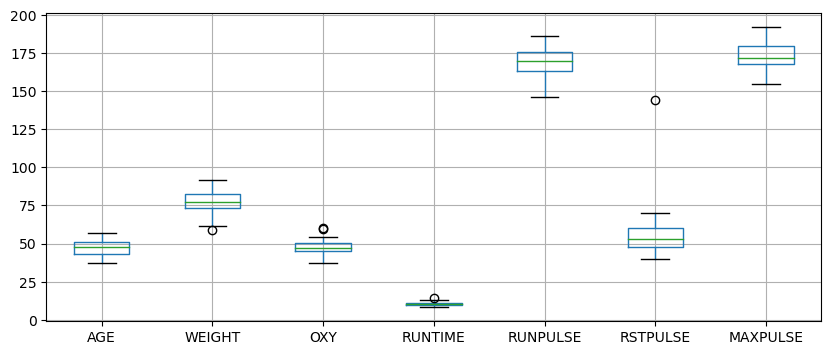

In [60]:
df_raw.boxplot(figsize = (10,4))

In [61]:
df_raw["RSTPULSE"] >=100
df_raw.loc[27:29]

,NAME,GENDER,AGE,AGEGROUP,WEIGHT,OXY,RUNTIME,RUNPULSE,RSTPULSE,MAXPULSE,BIRTH,RUNTIME_UNIT
27,Mark,남성,57,50대,73.37,39.407,12.63,174,58,176,1968-05-02,SEC
28,Steve,남성,54,50대,91.63,39.203,12.88,168,144,172,1969-11-03,SEC
29,Vaughn,남성,44,40대,81.42,39.442,13.08,174,63,176,1976-12-04,SEC


In [62]:
df_raw[(df_raw["RSTPULSE"] >=100)]

,NAME,GENDER,AGE,AGEGROUP,WEIGHT,OXY,RUNTIME,RUNPULSE,RSTPULSE,MAXPULSE,BIRTH,RUNTIME_UNIT
28,Steve,남성,54,50대,91.63,39.203,12.88,168,144,172,1969-11-03,SEC


In [63]:
df_fitness = df_raw[df_raw["RSTPULSE"] < 100]
df_fitness.loc[27:29]

,NAME,GENDER,AGE,AGEGROUP,WEIGHT,OXY,RUNTIME,RUNPULSE,RSTPULSE,MAXPULSE,BIRTH,RUNTIME_UNIT
27,Mark,남성,57,50대,73.37,39.407,12.63,174,58,176,1968-05-02,SEC
29,Vaughn,남성,44,40대,81.42,39.442,13.08,174,63,176,1976-12-04,SEC


In [64]:
df_fitness.reset_index(drop = True, inplace = True)
df_fitness.loc[27:29]

,NAME,GENDER,AGE,AGEGROUP,WEIGHT,OXY,RUNTIME,RUNPULSE,RSTPULSE,MAXPULSE,BIRTH,RUNTIME_UNIT
27,Mark,남성,57,50대,73.37,39.407,12.63,174,58,176,1968-05-02,SEC
28,Vaughn,남성,44,40대,81.42,39.442,13.08,174,63,176,1976-12-04,SEC
29,William,남성,45,40대,87.66,37.388,14.03,186,56,192,1979-08-05,SEC


In [65]:
df_fitness['BIRTH'] = pd.to_datetime(df_fitness['BIRTH'], format = '%Y-%m-%d')
df_fitness['YEAR'] = df_fitness['BIRTH'].dt.year
df_fitness['MONTH'] = df_fitness['BIRTH'].dt.month
df_fitness['DAY'] = df_fitness['BIRTH'].dt.day
df_fitness['WEEKDAY'] = df_fitness['BIRTH'].dt.weekday
df_fitness

/tmp/ipykernel_174689/191976689.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fitness['BIRTH'] = pd.to_datetime(df_fitness['BIRTH'], format = '%Y-%m-%d')
/tmp/ipykernel_174689/191976689.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fitness['YEAR'] = df_fitness['BIRTH'].dt.year
/tmp/ipykernel_174689/191976689.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docume

,NAME,GENDER,AGE,AGEGROUP,WEIGHT,OXY,RUNTIME,RUNPULSE,RSTPULSE,MAXPULSE,BIRTH,RUNTIME_UNIT,YEAR,MONTH,DAY,WEEKDAY
0,Donna,여성,42,40대,68.150,59.571,8.17,166,40,172,1976-04-05,SEC,1976,4,5,0
1,Gracie,여성,38,30대,81.870,60.055,8.63,170,48,186,1986-09-06,SEC,1986,9,6,5
2,Luanne,여성,43,40대,85.840,54.297,8.65,156,45,168,1978-04-07,SEC,1978,4,7,4
3,Mimi,여성,50,50대,70.870,54.625,8.92,146,48,155,1966-08-08,SEC,1966,8,8,0
4,Chris,남성,49,40대,82.427,49.156,8.95,180,44,185,1977-02-09,SEC,1977,2,9,2
5,Allen,남성,38,30대,89.020,49.874,9.22,178,55,180,1988-12-10,SEC,1988,12,10,5
6,Nancy,여성,49,40대,76.320,48.673,9.40,186,56,188,1977-06-11,SEC,1977,6,11,5
7,Patty,여성,52,50대,76.320,45.441,9.63,164,48,166,1969-05-12,SEC,1969,5,12,0
8,Suzanne,여성,57,50대,59.080,50.545,9.93,148,49,155,1964-11-13,SEC,1964,11,13,4
9,Teresa,여성,51,50대,77.910,46.672,10.00,162,48,168,1966-04-14,SEC,1966,4,14,3


In [66]:
df_fitness = df_fitness.drop(['NAME', 'BIRTH', 'RUNTIME_UNIT'], axis = 1)
df_fitness.head()

,GENDER,AGE,AGEGROUP,WEIGHT,OXY,RUNTIME,RUNPULSE,RSTPULSE,MAXPULSE,YEAR,MONTH,DAY,WEEKDAY
0,여성,42,40대,68.150,59.571,8.17,166,40,172,1976,4,5,0
1,여성,38,30대,81.870,60.055,8.63,170,48,186,1986,9,6,5
2,여성,43,40대,85.840,54.297,8.65,156,45,168,1978,4,7,4
3,여성,50,50대,70.870,54.625,8.92,146,48,155,1966,8,8,0
4,남성,49,40대,82.427,49.156,8.95,180,44,185,1977,2,9,2


In [67]:
df_fitness_dummy = pd.get_dummies(df_fitness, drop_first=True)
df_fitness_dummy.head()

,AGE,WEIGHT,OXY,RUNTIME,RUNPULSE,RSTPULSE,MAXPULSE,YEAR,MONTH,DAY,WEEKDAY,GENDER_여성,AGEGROUP_40대,AGEGROUP_50대
0,42,68.150,59.571,8.17,166,40,172,1976,4,5,0,1,1,0
1,38,81.870,60.055,8.63,170,48,186,1986,9,6,5,1,0,0
2,43,85.840,54.297,8.65,156,45,168,1978,4,7,4,1,1,0
3,50,70.870,54.625,8.92,146,48,155,1966,8,8,0,1,0,1
4,49,82.427,49.156,8.95,180,44,185,1977,2,9,2,0,1,0


In [73]:
df_scale_std = StandardScaler()
df_scale_std = df_scale_std.fit_transform(df_fitness_dummy)
df_scale_std = pd.DataFrame(df_scale_std, columns = df_fitness_dummy.columns)
df_scale_desc = df_scale_std.describe()
df_scale_desc.round(3)

,AGE,WEIGHT,OXY,RUNTIME,RUNPULSE,RSTPULSE,MAXPULSE,YEAR,MONTH,DAY,WEEKDAY,GENDER_여성,AGEGROUP_40대,AGEGROUP_50대
count,30.000,30.000,30.000,30.000,30.000,30.000,30.000,30.000,30.000,30.000,30.000,30.000,30.000,30.000
mean,-0.000,0.000,0.000,0.000,0.000,0.000,-0.000,0.000,0.000,0.000,-0.000,-0.000,0.000,0.000
std,1.017,1.017,1.017,1.017,1.017,1.017,1.017,1.017,1.017,1.017,1.017,1.017,1.017,1.017
min,-1.682,-2.261,-2.009,-1.772,-2.313,-1.857,-2.056,-1.608,-1.667,-1.700,-1.416,-1.069,-0.935,-0.707
25%,-0.631,-0.494,-0.486,-0.609,-0.703,-0.778,-0.637,-0.808,-0.815,-0.854,-0.916,-1.069,-0.935,-0.707
50%,0.158,-0.020,-0.122,-0.083,0.029,-0.171,-0.200,-0.008,-0.388,-0.008,-0.416,0.935,-0.935,-0.707
75%,0.771,0.678,0.511,0.491,0.615,0.672,0.673,0.361,1.033,0.839,1.083,0.935,1.069,1.414
max,1.822,1.836,2.429,2.666,1.591,2.189,1.984,1.838,1.459,1.685,1.582,0.935,1.069,1.414


In [95]:
mn = MinMaxScaler()
df_scale_minmax = mn.fit_transform(df_fitness_dummy)
df_scale_minmax = pd.DataFrame(df_scale_minmax, columns = df_fitness_dummy.columns)
df_scale_desc = df_scale_minmax.describe()
df_scale_desc.round(5)

,AGE,WEIGHT,OXY,RUNTIME,RUNPULSE,RSTPULSE,MAXPULSE,YEAR,MONTH,DAY,WEEKDAY,GENDER_여성,AGEGROUP_40대,AGEGROUP_50대
count,30.00000,30.00000,30.00000,30.00000,30.00000,30.00000,30.00000,30.00000,30.00000,30.00000,30.00000,30.00000,30.00000,30.00000
mean,0.48000,0.55188,0.45265,0.39926,0.59250,0.45889,0.50901,0.46667,0.53333,0.50230,0.47222,0.53333,0.46667,0.33333
std,0.29024,0.24827,0.22914,0.22919,0.26057,0.25138,0.25175,0.29509,0.32536,0.30043,0.33927,0.50742,0.50742,0.47946
min,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
25%,0.30000,0.43118,0.34318,0.26195,0.41250,0.26667,0.35135,0.23214,0.27273,0.25000,0.16667,0.00000,0.00000,0.00000
50%,0.52500,0.54700,0.42509,0.38055,0.60000,0.41667,0.45946,0.46429,0.40909,0.50000,0.33333,1.00000,0.00000,0.00000
75%,0.70000,0.71727,0.56785,0.50981,0.75000,0.62500,0.67568,0.57143,0.86364,0.75000,0.83333,1.00000,1.00000,1.00000
max,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000


In [96]:
df_scale_robust = RobustScaler().fit_transform(df_fitness_dummy)
df_scale_robust = pd.DataFrame(df_scale_robust, columns = df_fitness_dummy.columns)
df_sclae_desc = df_scale_robust.describe()
df_sclae_desc.round(3)

,AGE,WEIGHT,OXY,RUNTIME,RUNPULSE,RSTPULSE,MAXPULSE,YEAR,MONTH,DAY,WEEKDAY,GENDER_여성,AGEGROUP_40대,AGEGROUP_50대
count,30.000,30.000,30.000,30.000,30.000,30.000,30.000,30.000,30.000,30.000,30.000,30.000,30.000,30.000
mean,-0.112,0.017,0.123,0.076,-0.022,0.118,0.153,0.007,0.210,0.005,0.208,-0.467,0.467,0.333
std,0.726,0.868,1.020,0.925,0.772,0.702,0.776,0.870,0.551,0.601,0.509,0.507,0.507,0.479
min,-1.312,-1.912,-1.892,-1.535,-1.778,-1.163,-1.417,-1.368,-0.692,-1.000,-0.500,-1.000,0.000,0.000
25%,-0.562,-0.405,-0.365,-0.478,-0.556,-0.419,-0.333,-0.684,-0.231,-0.500,-0.250,-1.000,0.000,0.000
50%,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
75%,0.438,0.595,0.635,0.522,0.444,0.581,0.667,0.316,0.769,0.500,0.750,0.000,1.000,1.000
max,1.188,1.583,2.559,2.499,1.185,1.628,1.667,1.579,1.000,1.000,1.000,0.000,1.000,1.000


array([[<Axes: title={'center': 'RAW'}>,
        <Axes: title={'center': 'Standard'}>],
       [<Axes: title={'center': 'MinMax'}>,
        <Axes: title={'center': 'Robust'}>]], dtype=object)

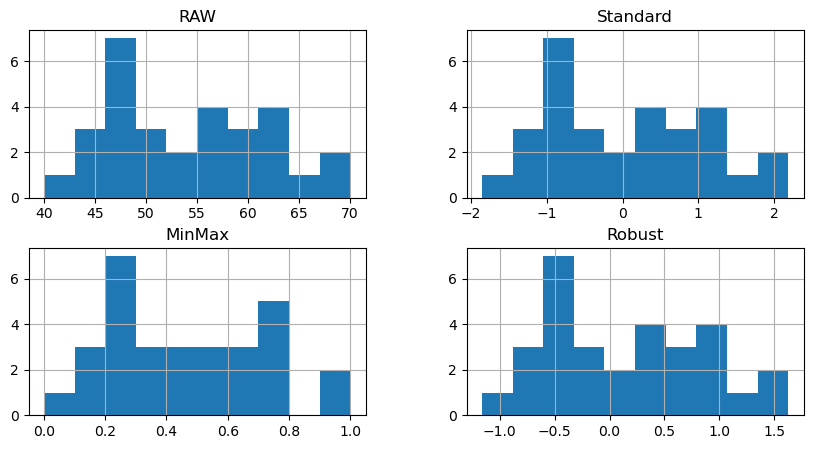

In [99]:
df_rstpulse = pd.DataFrame()
df_rstpulse["RAW"] = df_fitness_dummy["RSTPULSE"]
df_rstpulse["Standard"] = df_scale_std["RSTPULSE"]
df_rstpulse["MinMax"] = df_scale_minmax["RSTPULSE"]
df_rstpulse["Robust"] = df_scale_robust["RSTPULSE"]
df_rstpulse.head().round(3)
df_rstpulse[["RAW","Standard","MinMax", "Robust"]].hist(figsize = (10,5))

NameError: name 'preprocessing' is not defined